In [ ]:
#before running this please change the RUNTIME to GPU (Runtime -> Change runtime type -> set harware accelarotor as GPU)
#Mount our google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip3 install face_recognition

In [ ]:
#THis code is to check if the video is corrupted or not..
#If the video is corrupted delete the video.
import glob
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data.dataset import Dataset
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import face_recognition
#Check if the file is corrupted or not
def validate_video(vid_path,train_transforms):
      transform = train_transforms
      count = 20
      video_path = vid_path
      frames = []
      a = int(100/count)
      first_frame = np.random.randint(0,a)
      temp_video = video_path.split('/')[-1]
      for i,frame in enumerate(frame_extract(video_path)):
        frames.append(transform(frame))
        if(len(frames) == count):
          break
      frames = torch.stack(frames)
      frames = frames[:count]
      return frames
#extract a from from video
def frame_extract(path):
  vidObj = cv2.VideoCapture(path)
  success = 1
  while success:
      success, image = vidObj.read()
      if success:
          yield image

im_size = 112
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
                                        transforms.ToPILImage(),
                                        transforms.Resize((im_size,im_size)),
                                        transforms.ToTensor(),
                                        transforms.Normalize(mean,std)])
video_fil =  glob.glob('/content/drive/MyDrive/Face_only_data/*.mp4')

print(video_fil)
count = 0;
for i in video_fil:
  try:
    count+=1
    validate_video(i,train_transforms)
  except:
    print("Number of video processed: " , count ," Remaining : " , (len(video_fil) - count))
    print("Corrupted video is : " , i)
    continue
print((len(video_fil) - count))

['/content/drive/MyDrive/Face_only_data/otlcbjzoly.mp4', '/content/drive/MyDrive/Face_only_data/lvphdpcqlc.mp4', '/content/drive/MyDrive/Face_only_data/jvzvugshel.mp4', '/content/drive/MyDrive/Face_only_data/iyvcndziss.mp4', '/content/drive/MyDrive/Face_only_data/fdhmvpdhmg.mp4', '/content/drive/MyDrive/Face_only_data/oxdsqzexhu.mp4', '/content/drive/MyDrive/Face_only_data/dhlqlnupll.mp4', '/content/drive/MyDrive/Face_only_data/ofgjrewcmp.mp4', '/content/drive/MyDrive/Face_only_data/pqpgmvkxmd.mp4', '/content/drive/MyDrive/Face_only_data/eqmbljqgyr.mp4', '/content/drive/MyDrive/Face_only_data/pmpdirnxaj.mp4', '/content/drive/MyDrive/Face_only_data/rjqtuxhyoj.mp4', '/content/drive/MyDrive/Face_only_data/npodmhsumc.mp4', '/content/drive/MyDrive/Face_only_data/kprwsebfzd.mp4', '/content/drive/MyDrive/Face_only_data/cjbmmgsrpn.mp4', '/content/drive/MyDrive/Face_only_data/hnqocyfmyk.mp4', '/content/drive/MyDrive/Face_only_data/hlgicjaytp.mp4', '/content/drive/MyDrive/Face_only_data/hombhxah

In [ ]:
#to load preprocessod video to memory
import json
import glob
import numpy as np
import cv2
import copy
import random
video_files = glob.glob('/content/drive/MyDrive/Face_only_data/*.mp4')
random.shuffle(video_files)
random.shuffle(video_files)
frame_count = []
for video_file in video_files:
  cap = cv2.VideoCapture(video_file)
  if(int(cap.get(cv2.CAP_PROP_FRAME_COUNT))<100):
    video_files.remove(video_file)
    continue
  frame_count.append(int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
print("frames are " , frame_count)
print("Total no of video: " , len(frame_count))
print('Average frame per video:',np.mean(frame_count))

frames are  [148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 146, 148, 148, 148, 148, 148, 148, 148, 146, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 14

In [ ]:
# load the video name and labels from csv
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data.dataset import Dataset
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import face_recognition
class video_dataset(Dataset):
    def __init__(self,video_names,labels,sequence_length = 60,transform = None):
        self.video_names = video_names
        self.labels = labels
        self.transform = transform
        self.count = sequence_length
    def __len__(self):
        return len(self.video_names)
    def __getitem__(self,idx):
        video_path = self.video_names[idx]
        frames = []
        a = int(100/self.count)
        first_frame = np.random.randint(0,a)
        temp_video = video_path.split('/')[-1]
        #print(temp_video)
        label = self.labels.iloc[(labels.loc[labels["file"] == temp_video].index.values[0]),1]
        if(label == 'FAKE'):
          label = 0
        if(label == 'REAL'):
          label = 1
        for i,frame in enumerate(self.frame_extract(video_path)):
          frames.append(self.transform(frame))
          if(len(frames) == self.count):
            break
        frames = torch.stack(frames)
        frames = frames[:self.count]
        #print("length:" , len(frames), "label",label)
        return frames,label
    def frame_extract(self,path):
      vidObj = cv2.VideoCapture(path)
      success = 1
      while success:
          success, image = vidObj.read()
          if success:
              yield image
#plot the image
def im_plot(tensor):
    image = tensor.cpu().numpy().transpose(1,2,0)
    b,g,r = cv2.split(image)
    image = cv2.merge((r,g,b))
    image = image*[0.22803, 0.22145, 0.216989] +  [0.43216, 0.394666, 0.37645]
    image = image*255.0
    plt.imshow(image.astype(int))
    plt.show()

In [ ]:
def number_of_real_and_fake_videos(data_list):
    real = 0
    fake = 0

    label_dict = dict(zip(labels["file"], labels["label"]))

    for i in data_list:
        temp_video = i.split('/')[-1]

        if temp_video not in label_dict:
            continue

        if label_dict[temp_video] == "FAKE":
            fake += 1
        else:
            real += 1

    return real, fake

In [ ]:
import os
import pandas as pd

real_path = "/content/drive/MyDrive/dataset/Real_videos"
fake_path = "/content/drive/MyDrive/dataset/Fake_videos"

data = []

# REAL videos
for file in os.listdir(real_path):
    if file.endswith(".mp4"):
        data.append([file, "REAL"])

# FAKE videos
for file in os.listdir(fake_path):
    if file.endswith(".mp4"):
        data.append([file, "FAKE"])

# Create DataFrame
df = pd.DataFrame(data, columns=["file", "label"])

# Save CSV
df.to_csv("/content/labels.csv", index=False)

print("✅ CSV created successfully!")
print(df.head())

✅ CSV created successfully!
             file label
0  qefqgbtfhk.mp4  REAL
1  agaxevrqio.mp4  REAL
2  azdqkgvdbd.mp4  REAL
3  clvzmwiouq.mp4  REAL
4  fcylgaelfy.mp4  REAL


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


train :  530
test :  133
TRAIN:  Real: 87  Fake: 443
TEST:  Real: 17  Fake: 116


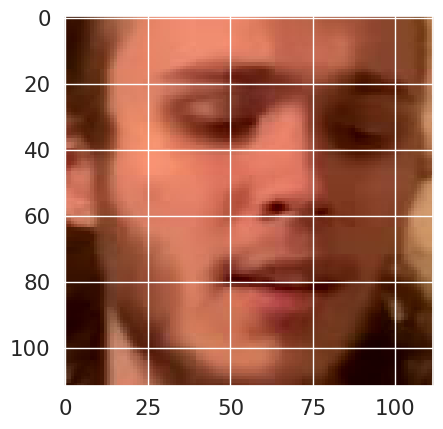

In [ ]:
import random
import pandas as pd
from sklearn.model_selection import train_test_split

# Correctly load the labels.csv, assuming it has a header row.
labels = pd.read_csv('/content/labels.csv')

# Create a set of valid video filenames from the labels DataFrame for efficient lookup
labeled_video_filenames = set(labels["file"].tolist())

# Filter video_files to only include those that have a label
filtered_video_files = [v for v in video_files if v.split('/')[-1] in labeled_video_filenames]

# Now use filtered_video_files for splitting
train_videos = filtered_video_files[:int(0.8*len(filtered_video_files))]
valid_videos = filtered_video_files[int(0.8*len(filtered_video_files)):]

print("train : ", len(train_videos))
print("test : ", len(valid_videos))

print("TRAIN: ", "Real:",number_of_real_and_fake_videos(train_videos)[0]," Fake:",number_of_real_and_fake_videos(train_videos)[1])
print("TEST: ", "Real:",number_of_real_and_fake_videos(valid_videos)[0]," Fake:",number_of_real_and_fake_videos(valid_videos)[1])

im_size = 112
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
                                        transforms.ToPILImage(),
                                        transforms.Resize((im_size,im_size)),
                                        transforms.ToTensor(),
                                        transforms.Normalize(mean,std)])

test_transforms = transforms.Compose([
                                        transforms.ToPILImage(),
                                        transforms.Resize((im_size,im_size)),
                                        transforms.ToTensor(),
                                        transforms.Normalize(mean,std)])
train_data = video_dataset(train_videos,labels,sequence_length = 10,transform = train_transforms)
val_data = video_dataset(valid_videos,labels,sequence_length = 10,transform = train_transforms)
train_loader = DataLoader(train_data,batch_size = 4,shuffle = True,num_workers = 4)
valid_loader = DataLoader(val_data,batch_size = 4,shuffle = True,num_workers = 4)
image,label = train_data[0]
im_plot(image[0,:,:,:])

In [ ]:
import torch
import torch.nn as nn

In [ ]:
import numpy as np
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

In [ ]:
class Model(nn.Module):
    def __init__(self, num_classes):
        super(Model, self).__init__()

        self.backbone = efficientnet_b0(
            weights=EfficientNet_B0_Weights.DEFAULT
        )

        # EfficientNet uses `classifier`, not `fc`
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        B, T, C, H, W = x.shape

        x = x.view(B * T, C, H, W)
        x = self.backbone(x)

        x = x.view(B, T, -1)
        x = torch.mean(x, dim=1)

        return x, x

In [ ]:
model = Model(2).cuda()
a,b = model(torch.from_numpy(np.empty((1,20,3,112,112))).type(torch.cuda.FloatTensor))

In [ ]:
import torch
from torch.autograd import Variable
import time
import os
import sys
import os
def train_epoch(epoch, num_epochs, data_loader, model, criterion, optimizer):
    model.train()
    losses = AverageMeter()
    accuracies = AverageMeter()
    t = []
    for i, (inputs, targets) in enumerate(data_loader):
        if torch.cuda.is_available():
            targets = targets.type(torch.cuda.LongTensor)
            inputs = inputs.cuda()
        _,outputs = model(inputs)
        loss  = criterion(outputs,targets.type(torch.cuda.LongTensor))
        acc = calculate_accuracy(outputs, targets.type(torch.cuda.LongTensor))
        losses.update(loss.item(), inputs.size(0))
        accuracies.update(acc, inputs.size(0))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        sys.stdout.write(
                "\r[Epoch %d/%d] [Batch %d / %d] [Loss: %f, Acc: %.2f%%]"
                % (
                    epoch,
                    num_epochs,
                    i,
                    len(data_loader),
                    losses.avg,
                    accuracies.avg))
    torch.save(model.state_dict(),'/content/checkpoint.pt')
    return losses.avg,accuracies.avg
def test(epoch,model, data_loader ,criterion):
    print('Testing')
    model.eval()
    losses = AverageMeter()
    accuracies = AverageMeter()
    pred = []
    true = []
    count = 0
    with torch.no_grad():
        for i, (inputs, targets) in enumerate(data_loader):
            if torch.cuda.is_available():
                targets = targets.cuda().type(torch.cuda.FloatTensor)
                inputs = inputs.cuda()
            _,outputs = model(inputs)
            loss = torch.mean(criterion(outputs, targets.type(torch.cuda.LongTensor)))
            acc = calculate_accuracy(outputs,targets.type(torch.cuda.LongTensor))
            _,p = torch.max(outputs,1)
            true += (targets.type(torch.cuda.LongTensor)).detach().cpu().numpy().reshape(len(targets)).tolist()
            pred += p.detach().cpu().numpy().reshape(len(p)).tolist()
            losses.update(loss.item(), inputs.size(0))
            accuracies.update(acc, inputs.size(0))
            sys.stdout.write(
                    "\r[Batch %d / %d]  [Loss: %f, Acc: %.2f%%]"
                    % (
                        i,
                        len(data_loader),
                        losses.avg,
                        accuracies.avg
                        )
                    )
        print('\nAccuracy {}'.format(accuracies.avg))
    return true,pred,losses.avg,accuracies.avg
class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()
    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count
def calculate_accuracy(outputs, targets):
    batch_size = targets.size(0)

    _, pred = outputs.topk(1, 1, True)
    pred = pred.t()
    correct = pred.eq(targets.view(1, -1))
    n_correct_elems = correct.float().sum().item()
    return 100* n_correct_elems / batch_size

In [ ]:
import seaborn as sn
#Output confusion matrix
def print_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    print('True positive = ', cm[0][0])
    print('False positive = ', cm[0][1])
    print('False negative = ', cm[1][0])
    print('True negative = ', cm[1][1])
    print('\n')
    df_cm = pd.DataFrame(cm, range(2), range(2))
    sn.set(font_scale=1.4) # for label size
    sn.heatmap(df_cm, annot=True, annot_kws={"size": 16}) # font size
    plt.ylabel('Actual label', size = 20)
    plt.xlabel('Predicted label', size = 20)
    plt.xticks(np.arange(2), ['Fake', 'Real'], size = 16)
    plt.yticks(np.arange(2), ['Fake', 'Real'], size = 16)
    plt.ylim([2, 0])
    plt.show()
    calculated_acc = (cm[0][0]+cm[1][1])/(cm[0][0]+cm[0][1]+cm[1][0]+ cm[1][1])
    print("Calculated Accuracy",calculated_acc*100)

In [ ]:
def plot_loss(train_loss_avg,test_loss_avg,num_epochs):
  loss_train = train_loss_avg
  loss_val = test_loss_avg
  print(num_epochs)
  epochs = range(1,num_epochs+1)
  plt.plot(epochs, loss_train, 'g', label='Training loss')
  plt.plot(epochs, loss_val, 'b', label='validation loss')
  plt.title('Training and Validation loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()
def plot_accuracy(train_accuracy,test_accuracy,num_epochs):
  loss_train = train_accuracy
  loss_val = test_accuracy
  epochs = range(1,num_epochs+1)
  plt.plot(epochs, loss_train, 'g', label='Training accuracy')
  plt.plot(epochs, loss_val, 'b', label='validation accuracy')
  plt.title('Training and Validation accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.show()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[Epoch 1/25] [Batch 132 / 133] [Loss: 0.647211, Acc: 68.68%]Testing
[Batch 33 / 34]  [Loss: 0.586059, Acc: 81.20%]
Accuracy 81.203007518797
[Epoch 2/25] [Batch 132 / 133] [Loss: 0.540307, Acc: 83.58%]Testing
[Batch 33 / 34]  [Loss: 0.494285, Acc: 89.47%]
Accuracy 89.47368421052632
[Epoch 3/25] [Batch 132 / 133] [Loss: 0.469457, Acc: 84.34%]Testing
[Batch 33 / 34]  [Loss: 0.438497, Acc: 87.97%]
Accuracy 87.96992481203007
[Epoch 4/25] [Batch 132 / 133] [Loss: 0.406480, Acc: 86.79%]Testing
[Batch 33 / 34]  [Loss: 0.382292, Acc: 88.72%]
Accuracy 88.7218045112782
[Epoch 5/25] [Batch 132 / 133] [Loss: 0.369683, Acc: 86.23%]Testing
[Batch 33 / 34]  [Loss: 0.326446, Acc: 90.23%]
Accuracy 90.22556390977444
[Epoch 6/25] [Batch 132 / 133] [Loss: 0.342413, Acc: 86.60%]Testing
[Batch 33 / 34]  [Loss: 0.297181, Acc: 90.23%]
Accuracy 90.22556390977444
[Epoch 7/25] [Batch 132 / 133] [Loss: 0.313842, Acc: 87.74%]Testing
[Batch 33 / 34]  [Loss: 0.272540, Acc: 91.73%]
Accuracy 91.72932330827068
[Epoch 8/

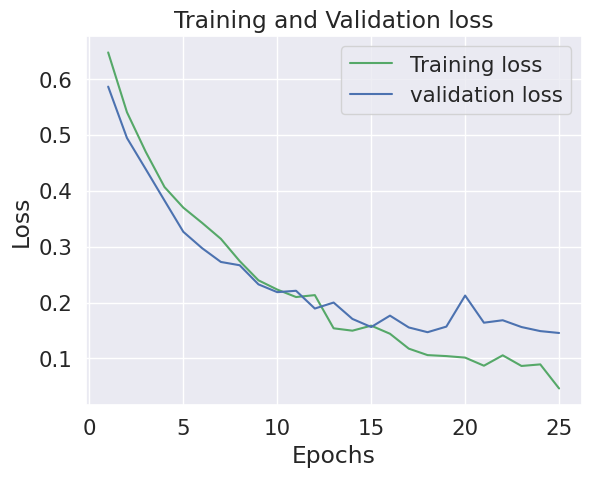

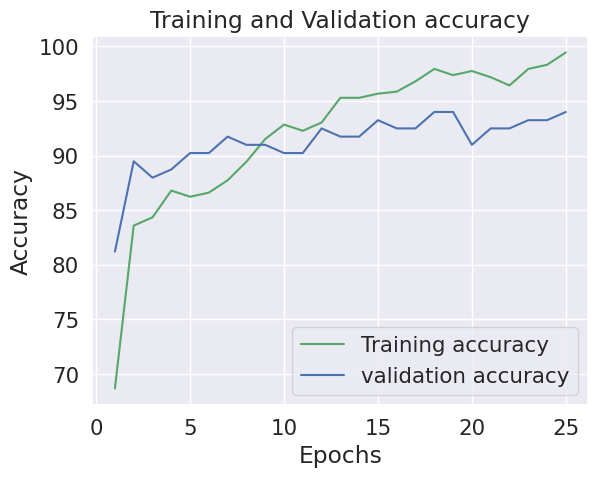

[[110   6]
 [  2  15]]
True positive =  110
False positive =  6
False negative =  2
True negative =  15




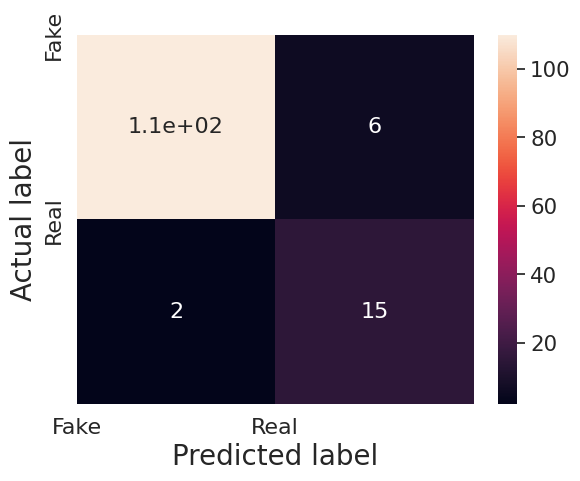

Calculated Accuracy 93.98496240601504


In [ ]:
from sklearn.metrics import confusion_matrix
#learning rate
lr = 1e-5#0.001
#number of epochs
num_epochs = 25

optimizer = torch.optim.Adam(model.parameters(), lr= lr,weight_decay = 1e-5)

#class_weights = torch.from_numpy(np.asarray([1,15])).type(torch.FloatTensor).cuda()
#criterion = nn.CrossEntropyLoss(weight = class_weights).cuda()
criterion = nn.CrossEntropyLoss().cuda()
train_loss_avg =[]
train_accuracy = []
test_loss_avg = []
test_accuracy = []
for epoch in range(1,num_epochs+1):
    l, acc = train_epoch(epoch,num_epochs,train_loader,model,criterion,optimizer)
    train_loss_avg.append(l)
    train_accuracy.append(acc)
    true,pred,tl,t_acc = test(epoch,model,valid_loader,criterion)
    test_loss_avg.append(tl)
    test_accuracy.append(t_acc)
plot_loss(train_loss_avg,test_loss_avg,len(train_loss_avg))
plot_accuracy(train_accuracy,test_accuracy,len(train_accuracy))
print(confusion_matrix(true,pred))
print_confusion_matrix(true,pred)

In [ ]:
from sklearn.metrics import classification_report

# Assuming 'true' and 'pred' are available from the previous model evaluation
print(classification_report(true, pred, target_names=['Fake', 'Real']))

              precision    recall  f1-score   support

        Fake       0.98      0.95      0.96       116
        Real       0.71      0.88      0.79        17

    accuracy                           0.94       133
   macro avg       0.85      0.92      0.88       133
weighted avg       0.95      0.94      0.94       133



In [ ]:
import torch

torch.save(model.state_dict(), "deepfake_model.pth")